In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# Fake News Detection Dataset

from pandas import read_csv

df = read_csv("/content/Fake_News_Detection_Dataset_2000.csv")

print(df.head())

   News_ID                                   Title  \
0    41376    Officials Announce New Policy Update   
1     8711   URGENT REPORT: Hidden Details Exposed   
2    43651  Researchers Publish New Study Findings   
3    12638            Secret Truth Revealed Online   
4    37308    Officials Announce New Policy Update   

                                                Text              Source  \
0  Researchers reported findings from a study and...      Times of India   
1  SHOCKING NEWS: A controversial claim has appea...  Viral News Network   
2  The company released its quarterly results and...                NDTV   
3  SHOCKING NEWS: A controversial claim has appea...      Unknown Source   
4  Researchers reported findings from a study and...    Associated Press   

      Subject          Author PublishedDate  TextLength  WordCount  \
0  Technology  Editorial Team    2019-06-20         241         34   
1      Health         Unknown    2022-08-06         220         34   
2  Techn

In [4]:
# Numerical vs Categorical features

numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = df.select_dtypes(
    include=['object']
).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['News_ID', 'TextLength', 'WordCount', 'SentimentScore', 'CapitalWordRatio', 'PunctuationCount', 'URLCount', 'ExclamationCount', 'QuestionCount', 'ReadabilityScore', 'SourceCredibilityScore', 'class']
Categorical Features: ['Title', 'Text', 'Source', 'Subject', 'Author', 'PublishedDate']


In [5]:
# Select only numerical columns for correlation

numerical_cols = df.select_dtypes(
    include=[np.number]
).columns.tolist()

corr_matrix = df[numerical_cols].corr()

In [6]:
# Print matrix to terminal

print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                         News_ID  TextLength  WordCount  SentimentScore  \
News_ID                 1.000000    0.722375   0.244410       -0.633297   
TextLength              0.722375    1.000000   0.313925       -0.599706   
WordCount               0.244410    0.313925   1.000000       -0.205684   
SentimentScore         -0.633297   -0.599706  -0.205684        1.000000   
CapitalWordRatio       -0.410281   -0.412580  -0.136560        0.345880   
PunctuationCount       -0.431236   -0.382437  -0.219917        0.388046   
URLCount               -0.257101   -0.270740  -0.088371        0.228907   
ExclamationCount       -0.864625   -0.846246  -0.285495        0.732818   
QuestionCount                NaN         NaN        NaN             NaN   
ReadabilityScore        0.282734    0.255953   0.098352       -0.222915   
SourceCredibilityScore  0.764773    0.747098   0.249889       -0.662905   
class                   0.864625    0.846246   0.285495       -0.732818 

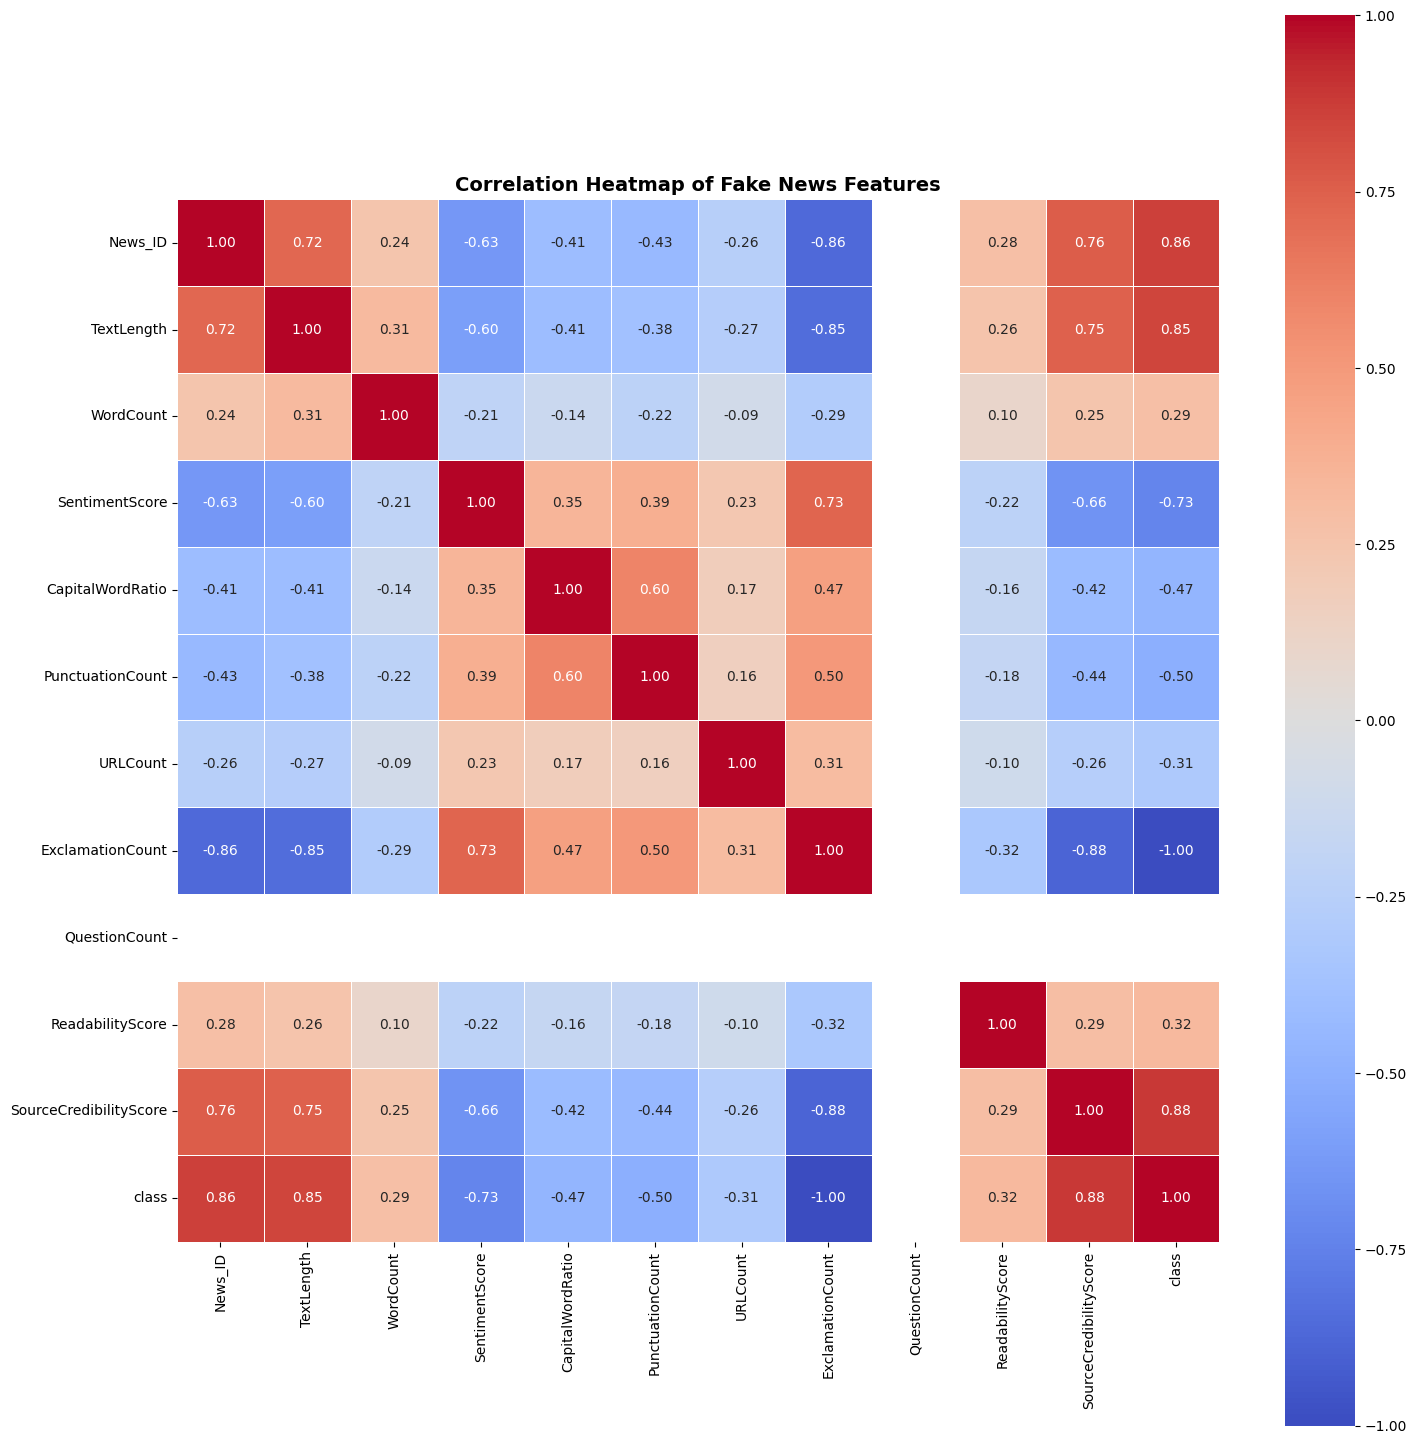

In [7]:
# Create Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Fake News Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

In [8]:
# Export Heatmap

import os

output_dir = "/content/"

heatmap_path = os.path.join(
    output_dir,
    "fake_news_correlation_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=300
)

plt.close()

print(
    f"Exported heatmap to: {heatmap_path}"
)

Exported heatmap to: /content/fake_news_correlation_heatmap.png


In [9]:
# -------------------------------------------------------------
# Produce Boxplots: Numerical Features vs Fake News Class
# -------------------------------------------------------------

target_col = "class"

if target_col in df.columns:

    for col in numerical_cols:

        # News_ID is only an identifier, so exclude it
        if col != "News_ID" and col != target_col:

            plt.figure(figsize=(6, 5))

            sns.boxplot(
                x=target_col,
                y=col,
                data=df,
                hue=target_col,
                legend=False
            )

            plt.title(
                f"{col} vs Fake News Class"
            )

            plt.xlabel(
                "News Class (0 = Real, 1 = Fake)"
            )

            plt.ylabel(col)

            plt.tight_layout()

            boxplot_filename = (
                f"boxplot_{col}_vs_{target_col}.png"
            )

            boxplot_path = os.path.join(
                output_dir,
                boxplot_filename
            )

            plt.savefig(
                boxplot_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close()

            print(
                f"Exported boxplot to: {boxplot_path}"
            )

else:

    print(
        f"\nTarget column '{target_col}' not found."
    )

print("\nAll boxplot EDA tasks completed successfully!")

Exported boxplot to: /content/boxplot_TextLength_vs_class.png
Exported boxplot to: /content/boxplot_WordCount_vs_class.png
Exported boxplot to: /content/boxplot_SentimentScore_vs_class.png
Exported boxplot to: /content/boxplot_CapitalWordRatio_vs_class.png
Exported boxplot to: /content/boxplot_PunctuationCount_vs_class.png
Exported boxplot to: /content/boxplot_URLCount_vs_class.png
Exported boxplot to: /content/boxplot_ExclamationCount_vs_class.png
Exported boxplot to: /content/boxplot_QuestionCount_vs_class.png
Exported boxplot to: /content/boxplot_ReadabilityScore_vs_class.png
Exported boxplot to: /content/boxplot_SourceCredibilityScore_vs_class.png

All boxplot EDA tasks completed successfully!


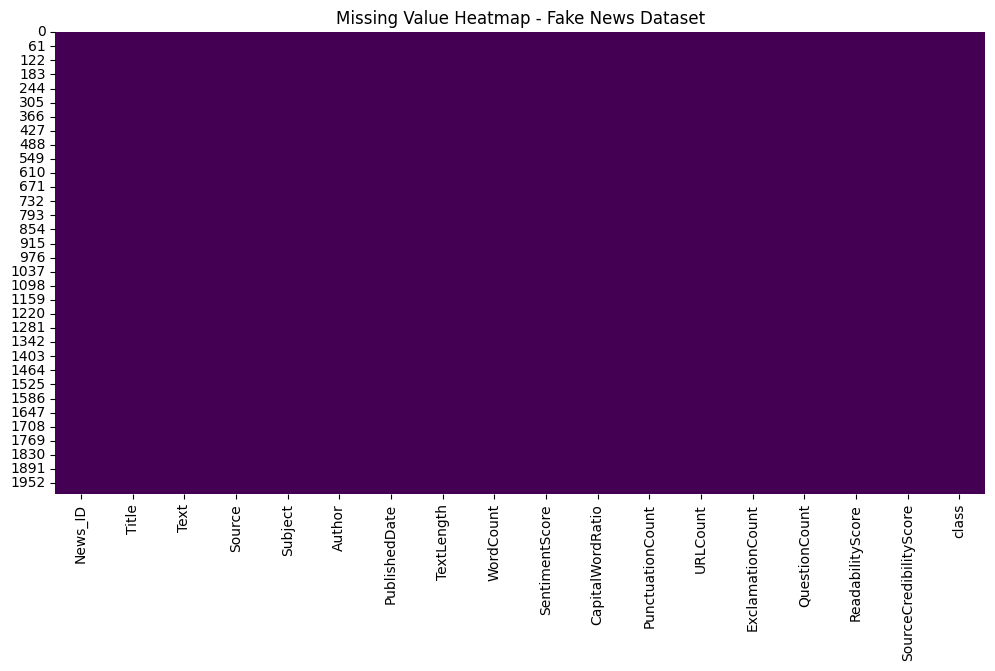

In [10]:
import matplotlib.pyplot as plt

fig1 = plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap - Fake News Dataset")

plt.show()

<Figure size 1500x800 with 0 Axes>

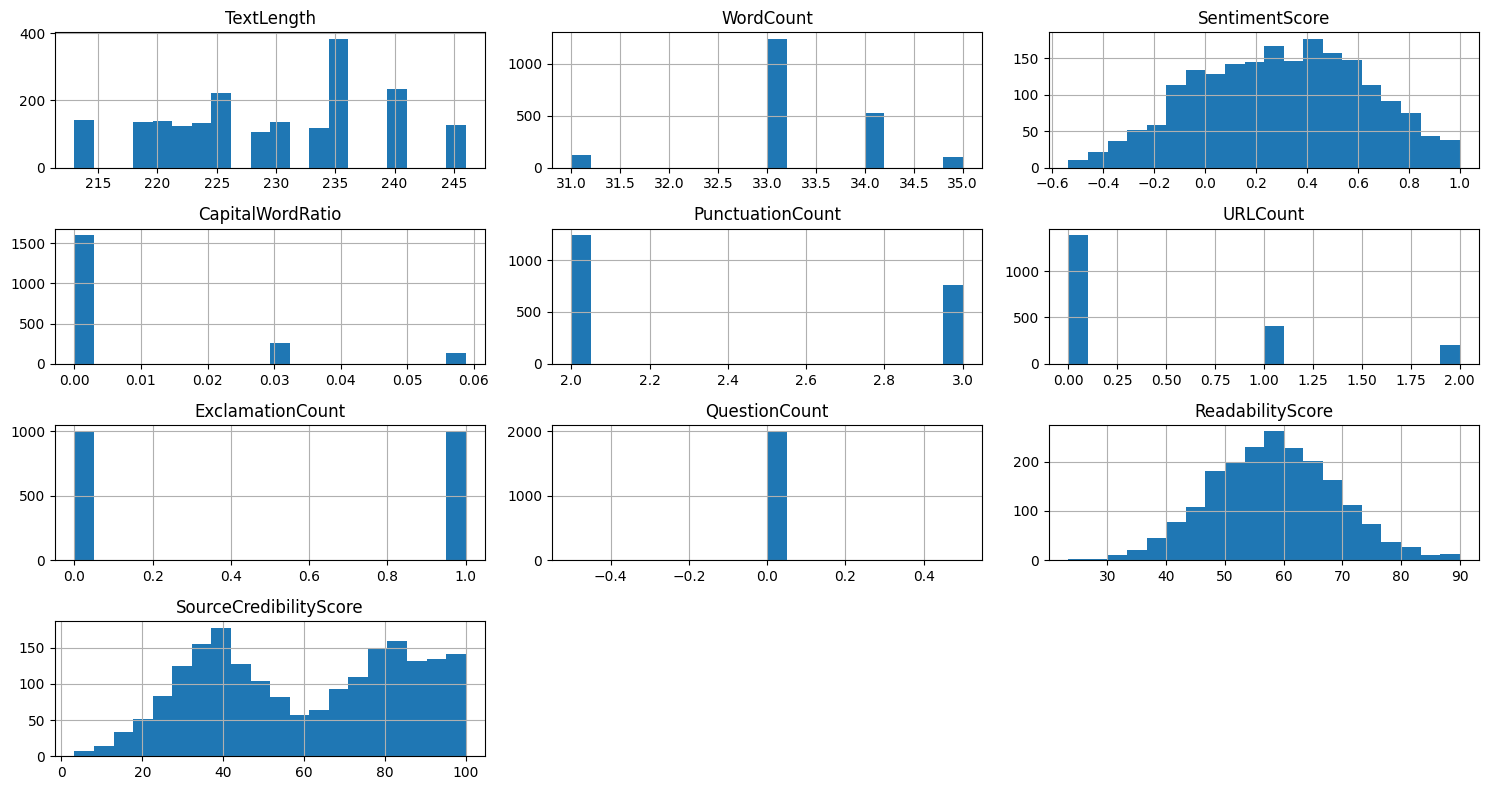

In [12]:
features = [
    "TextLength",
    "WordCount",
    "SentimentScore",
    "CapitalWordRatio",
    "PunctuationCount",
    "URLCount",
    "ExclamationCount",
    "QuestionCount",
    "ReadabilityScore",
    "SourceCredibilityScore"
]

fig2 = plt.figure(figsize=(15, 8))

df[features].hist(
    bins=20,
    figsize=(15, 8)
)

plt.tight_layout()

plt.show()

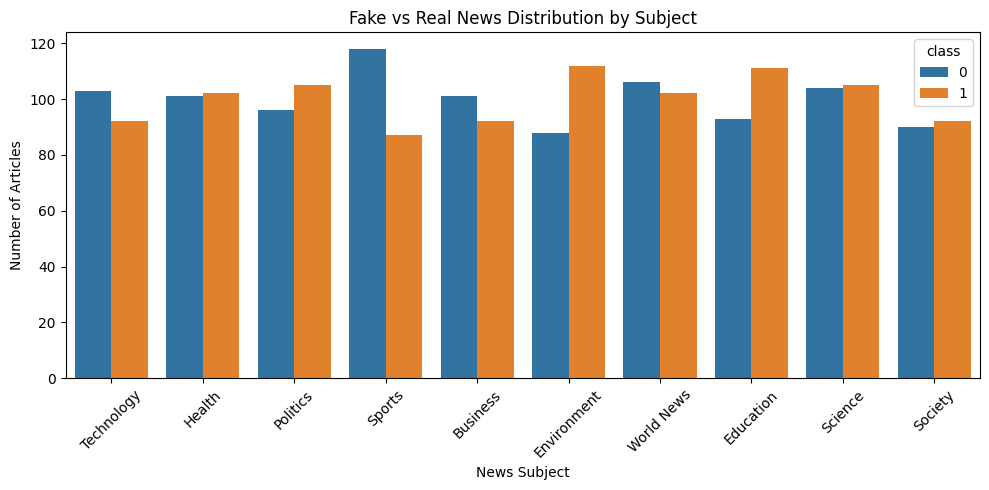

In [13]:
# Fake News Distribution by Subject

fig3 = plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Subject",
    hue="class"
)

plt.title(
    "Fake vs Real News Distribution by Subject"
)

plt.xlabel("News Subject")

plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

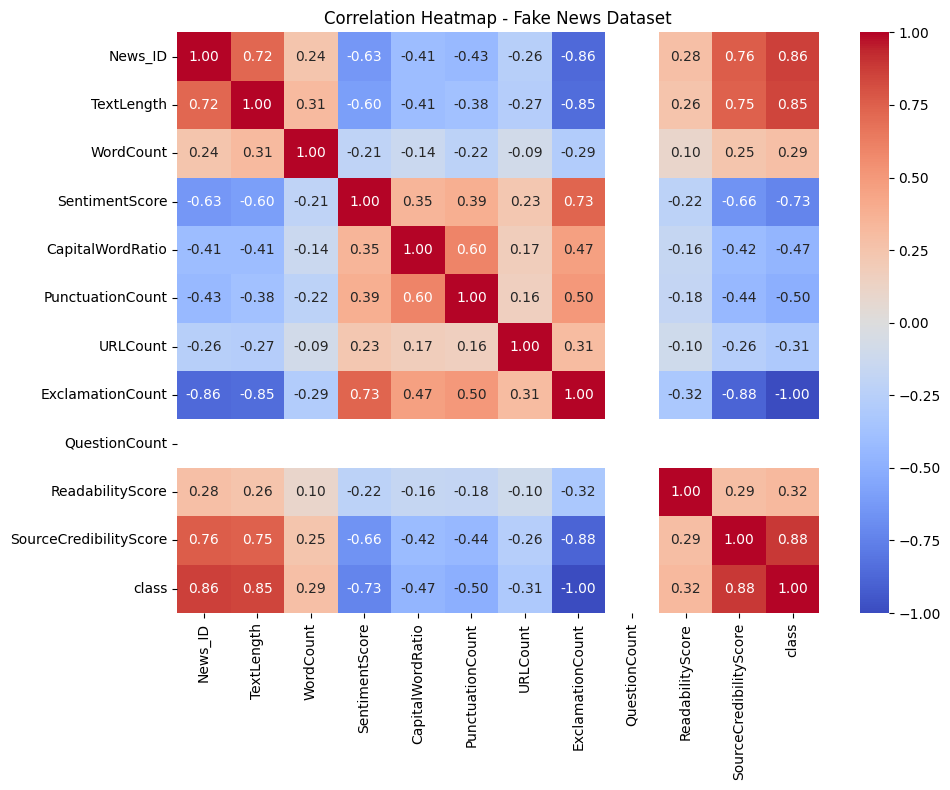

In [14]:
# Correlation Heatmap

fig5 = plt.figure(figsize=(10, 8))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap - Fake News Dataset"
)

plt.tight_layout()

plt.show()

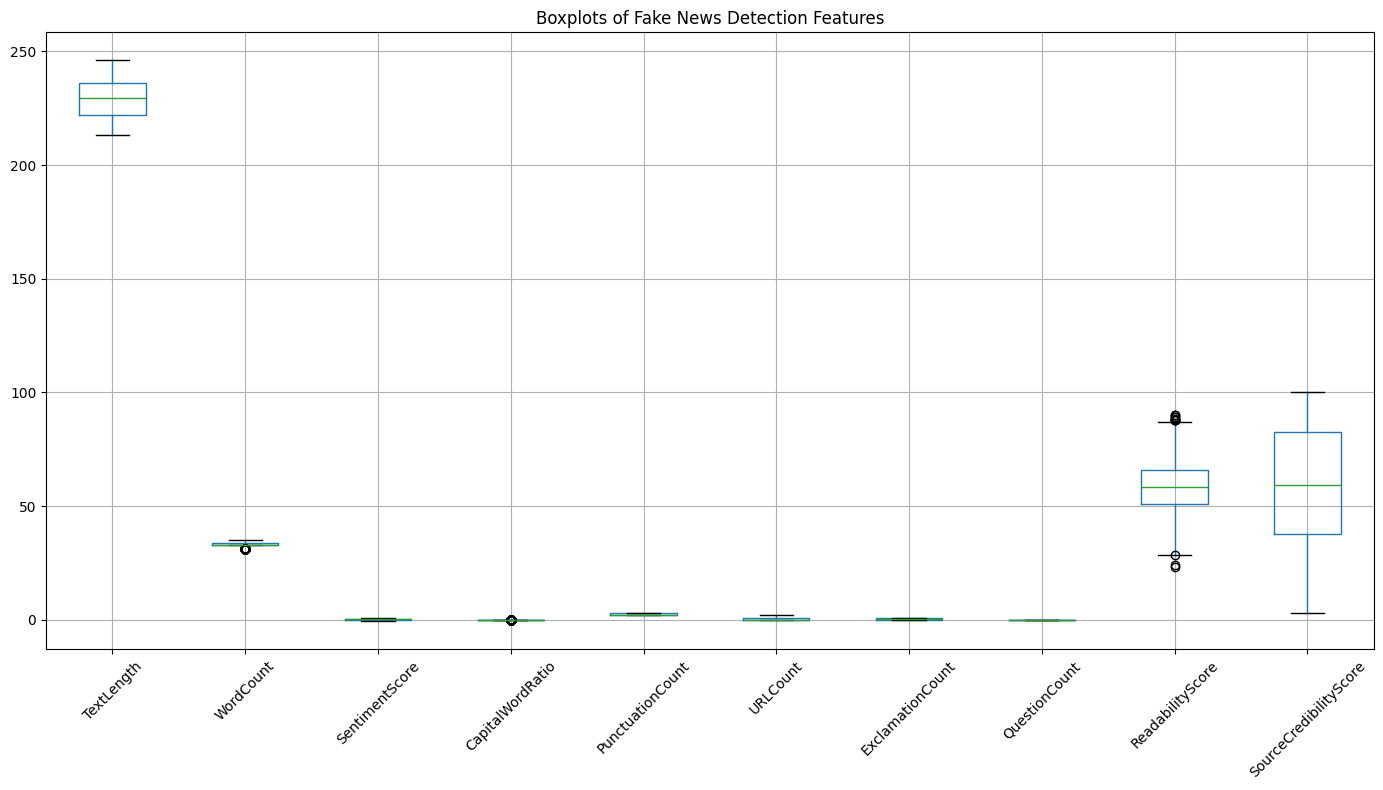

In [15]:
# Boxplots

numerical_columns = [
    "TextLength",
    "WordCount",
    "SentimentScore",
    "CapitalWordRatio",
    "PunctuationCount",
    "URLCount",
    "ExclamationCount",
    "QuestionCount",
    "ReadabilityScore",
    "SourceCredibilityScore"
]

fig6 = plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.title(
    "Boxplots of Fake News Detection Features"
)

plt.tight_layout()

plt.show()

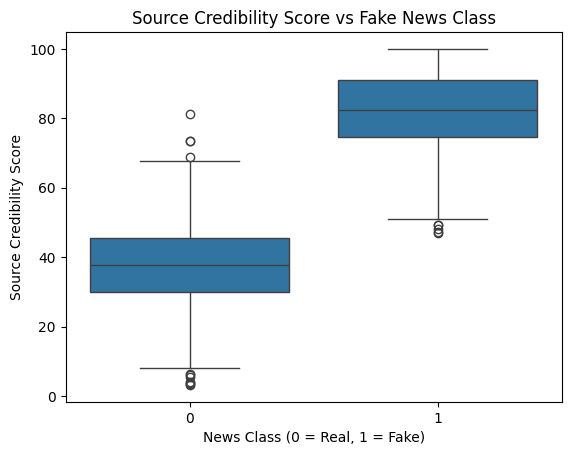

In [17]:
fig7 = sns.boxplot(
    x='class',
    y='SourceCredibilityScore',
    data=df
)

plt.title(
    "Source Credibility Score vs Fake News Class"
)

plt.xlabel(
    "News Class (0 = Real, 1 = Fake)"
)

plt.ylabel(
    "Source Credibility Score"
)

plt.show()

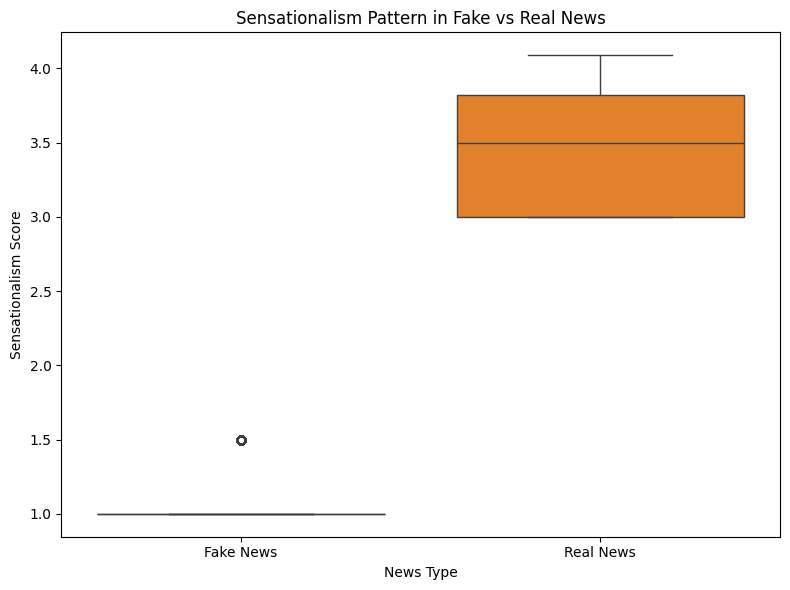

In [19]:
# Project-specific analysis:
# Creating a Sensationalism Score

df["SensationalismScore"] = (
    df["ExclamationCount"] * 2
    + df["CapitalWordRatio"] * 10
    + df["PunctuationCount"] * 0.5
)

df["News_Type"] = df["class"].map({
    0: "Real News",
    1: "Fake News"
})

fig8 = plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="News_Type",
    y="SensationalismScore",
    hue="News_Type",
    legend=False
)

plt.title(
    "Sensationalism Pattern in Fake vs Real News"
)

plt.xlabel("News Type")

plt.ylabel("Sensationalism Score")

plt.tight_layout()

plt.show()

In [18]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("Fake_News_EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)
    pdf.savefig(fig7.figure)

print("Fake News EDA Report saved successfully.")

Fake News EDA Report saved successfully.
